# Coordinación semafórica — Onda verde en Av. Luis Elizondo (Distrito Tec)

**Reto Integrador – TC2008 (Sistemas Multiagente).**

Corredor de **3 intersecciones** sobre Av. Luis Elizondo:

1. **Fernando García Roel / Cantú Leal**
2. **Junco de la Vega** (cruce en T)
3. **Eugenio Garza Sada**

Este cuaderno calcula los **offsets** de coordinación, dibuja el **diagrama
espacio–tiempo** con bandas verdes y trayectorias, y evalúa el **ancho de banda**
y la **progresión vehicular** (qué tan bien se mantiene la onda verde).

> Nota: las distancias son aproximadas medidas en Google Maps y deben confirmarse.
> Los volúmenes son estimaciones razonables mientras se obtienen los datos reales.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Parámetros del corredor y justificación

**Distancias entre intersecciones** (medidas en Google Maps, eje del corredor):

| Tramo | Distancia |
|---|---|
| García Roel → Junco | 345 m |
| Junco → Garza Sada | 500 m |

**Velocidad de sincronía: 40 km/h.** Se justifica porque es una avenida urbana
dentro del Distrito Tec, con presencia de peatones, paradas y campus, donde una
progresión de 40 km/h es realista y segura (por debajo de arterias de 50–60 km/h).

**Ciclo semafórico:** C = 66 s, con **verde coordinado = 45 s**, amarillo = 3 s,
rojo = 18 s. Se da verde amplio a Av. Luis Elizondo por ser el corredor principal
(las transversales reciben el resto del ciclo).

In [ ]:
intersections = pd.DataFrame({
    'id':     ['I1', 'I2', 'I3'],
    'nombre': ['Fernando García Roel', 'Junco de la Vega', 'Eugenio Garza Sada'],
    'dist_m': [0, 345, 845],
})

C        = 66.0
verde    = 45.0
amarillo = 3.0
rojo     = 18.0
v_kmh    = 40.0
v        = v_kmh * 1000 / 3600

print(f'Velocidad de sincronía: {v_kmh} km/h = {v:.2f} m/s')
print(f'Ciclo C = {C}s  (verde {verde}s / amarillo {amarillo}s / rojo {rojo}s)')
print(f'Split de verde coordinado = {verde/C:.0%}')
intersections

Velocidad de sincronía: 40.0 km/h = 11.11 m/s
Ciclo C = 66.0s  (verde 45.0s / amarillo 3.0s / rojo 18.0s)
Split de verde coordinado = 68%


,id,nombre,dist_m
0,I1,Fernando García Roel,0
1,I2,Junco de la Vega,345
2,I3,Eugenio Garza Sada,845


## 2. Cálculo de offsets

El **offset** es el desfase de arranque del verde entre intersecciones para que
un pelotón viaje sin detenerse:

$$ t_i = \frac{d_i - d_{i-1}}{v} \qquad Offset_i = (Offset_{i-1} + t_i)\bmod C $$

Para el sentido contrario el cálculo se hace desde la última intersección.

In [ ]:
def offsets_forward(d, v, C):
    o = [0.0]
    for i in range(1, len(d)):
        o.append((o[-1] + (d[i] - d[i-1]) / v) % C)
    return o

def offsets_reverse(d, v, C):
    o = [0.0] * len(d)
    for i in range(len(d) - 2, -1, -1):
        o[i] = (o[i+1] + (d[i+1] - d[i]) / v) % C
    return o

d = intersections['dist_m'].values
intersections['offset_fwd'] = np.round(offsets_forward(d, v, C), 2)
intersections['offset_rev'] = np.round(offsets_reverse(d, v, C), 2)
intersections

,id,nombre,dist_m,offset_fwd,offset_rev
0,I1,Fernando García Roel,0,0.00,10.05
1,I2,Junco de la Vega,345,31.05,45.00
2,I3,Eugenio Garza Sada,845,10.05,0.00


Los offsets (0 / 31.1 / 10.1 s en sentido García Roel→Garza Sada) coinciden con el
plan de coordinación del corredor: cada cruce abre su verde justo cuando el pelotón
que viaja a 40 km/h llega a él.

## 3. Diagrama espacio–tiempo (entregable clave)

- Eje X = tiempo, eje Y = posición sobre el corredor.
- Las **barras verdes** son las ventanas de verde coordinado de cada intersección.
- Las **barras rojas** son las ventanas de rojo calculadas matemáticamente con `(t - offset) % C`.
- Las **líneas azules** son trayectorias del pelotón (pendiente = velocidad de sincronía).
- Si una trayectoria cruza todas las barras verdes, la **onda verde se mantiene**.
- Flujo **unidireccional**: sentido Jesus Cantú → Garza Sada.

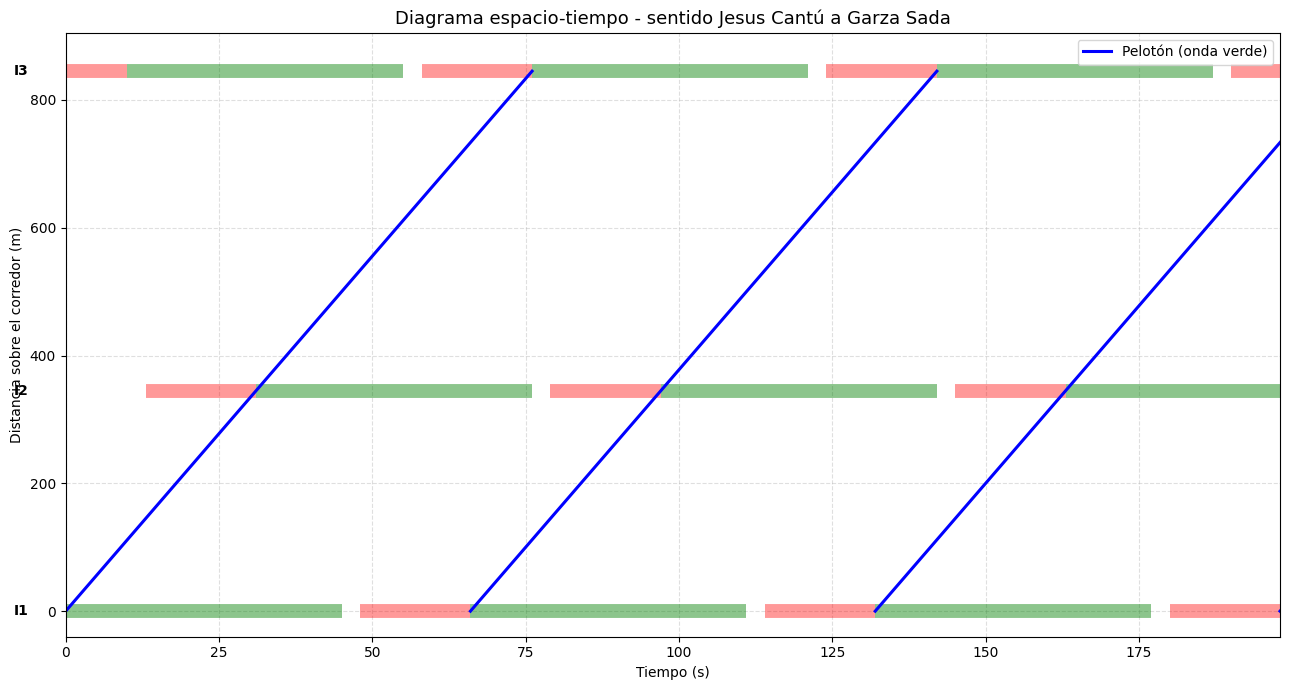

In [ ]:
import os
os.makedirs('figs', exist_ok=True)


def _draw_red_windows(ax, y, off, C, g, am, n_ciclos):
    T = C * n_ciclos
    for k in range(-2, n_ciclos + 2):
        rs = off + g + am + k * C
        re = off + C + k * C
        rs_c, re_c = max(0.0, rs), min(T, re)
        if rs_c < re_c:
            ax.hlines(y, rs_c, re_c, color='red', alpha=0.4, linewidth=10)


def diagrama_espacio_tiempo(inter, C, g, v, n_ciclos=3, nombre=None):
    fig, ax = plt.subplots(figsize=(13, 7))
    dmax = inter['dist_m'].max()

    for _, row in inter.iterrows():
        y   = row['dist_m']
        off = row['offset_fwd']
        for k in range(n_ciclos):
            start = off + k * C
            ax.hlines(y, start, start + g, color='green', linewidth=10, alpha=0.45)
        _draw_red_windows(ax, y, off, C, g, amarillo, n_ciclos)
        ax.text(-6, y, row['id'], va='center', ha='right', fontweight='bold')

    for k in range(n_ciclos + 1):
        t0 = inter['offset_fwd'].iloc[0] + k * C
        ax.plot([t0, t0 + dmax / v], [0, dmax], color='blue', lw=2.2,
                label='Pelotón (onda verde)' if k == 0 else None)

    titulo = nombre if nombre else 'Diagrama espacio-tiempo - sentido Jesus Cantú a Garza Sada'
    ax.set_title(titulo, fontsize=13)
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Distancia sobre el corredor (m)')
    ax.set_xlim(0, C * n_ciclos)
    ax.set_ylim(-40, dmax + 60)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right')
    slug = ''.join(c if c.isalnum() else '_' for c in titulo)[:50]
    plt.tight_layout()
    plt.savefig(f'figs/{slug}.png', dpi=120, bbox_inches='tight')
    plt.show()


diagrama_espacio_tiempo(intersections, C, verde, v)

## 4. Ancho de banda y progresión

El **ancho de banda** es el rango de tiempo (s) dentro del cual un vehículo puede
entrar al corredor y encontrar verde en **todas** las intersecciones. Es la medida
de qué tan buena es la coordinación.

In [ ]:
def ancho_de_banda(offsets, d, v, C, g, n=4000):
    ts = np.linspace(0, C, n, endpoint=False)
    ok = np.ones(n, dtype=bool)
    for off, di in zip(offsets, d):
        arr = (ts + di / v) % C
        ok &= ((arr - off) % C) <= g
    run = best = 0
    for b in np.concatenate([ok, ok]):
        run = run + 1 if b else 0
        best = max(best, run)
    return min(best, n) / n * C

of  = offsets_forward(d, v, C)
orv = offsets_reverse(d, v, C)
bw_f = ancho_de_banda(of,  d, v, C, verde)
bw_r = ancho_de_banda(orv, d, v, C, verde)

print(f'Ancho de banda  García Roel→Garza Sada: {bw_f:5.1f} s  ({bw_f/C:.0%} del ciclo)')
print(f'Ancho de banda  Garza Sada→García Roel: {bw_r:5.1f} s  ({bw_r/C:.0%} del ciclo)')
print(f'Eficiencia bidireccional promedio:      {(bw_f+bw_r)/2/C:.0%}')

Ancho de banda  García Roel→Garza Sada:  45.0 s  (68% del ciclo)
Ancho de banda  Garza Sada→García Roel:  21.0 s  (32% del ciclo)
Eficiencia bidireccional promedio:      50%


## 5. Evaluación de la progresión (¿llega en verde?)

Se simula un vehículo que sale en el instante óptimo y se verifica si llega en
verde a cada intersección.

In [ ]:
def evalua_progresion(inter, v, C, g, sentido='fwd'):
    d = inter['dist_m'].values
    nombres = inter['nombre'].values
    n = len(d)
    off = offsets_forward(d, v, C) if sentido == 'fwd' else offsets_reverse(d, v, C)
    idxs = range(n) if sentido == 'fwd' else range(n - 1, -1, -1)
    base = d[0] if sentido == 'fwd' else d[-1]
    t0   = off[0] if sentido == 'fwd' else off[-1]
    out  = []
    for i in idxs:
        tt = abs(d[i] - base) / v
        arr = (t0 + tt) % C
        en_verde = ((arr - off[i]) % C) <= g + 1e-9
        out.append({'interseccion': nombres[i], 't_llegada_s': round(tt, 1),
                    'offset_s': round(off[i], 2), 'llega_en_verde': en_verde})
    return pd.DataFrame(out)

ev_f = evalua_progresion(intersections, v, C, verde, 'fwd')
ev_r = evalua_progresion(intersections, v, C, verde, 'rev')
print('Sentido García Roel -> Garza Sada')
print(ev_f.to_string(index=False))
print('\nSentido Garza Sada -> García Roel')
print(ev_r.to_string(index=False))
print(f'\nProgresión en verde  fwd: {ev_f.llega_en_verde.mean():.0%} | rev: {ev_r.llega_en_verde.mean():.0%}')

Sentido García Roel -> Garza Sada
        interseccion  t_llegada_s  offset_s  llega_en_verde
Fernando García Roel          0.0      0.00            True
    Junco de la Vega         31.0     31.05            True
  Eugenio Garza Sada         76.0     10.05            True

Sentido Garza Sada -> García Roel
        interseccion  t_llegada_s  offset_s  llega_en_verde
  Eugenio Garza Sada          0.0      0.00            True
    Junco de la Vega         45.0     45.00            True
Fernando García Roel         76.0     10.05            True

Progresión en verde  fwd: 100% | rev: 100%


## 5b. Comparación: con onda verde vs sin coordinar

Se compara la estrategia **coordinada** (offsets calculados) contra un plan **sin
coordinar** (todos los semáforos con offset 0, mismo ciclo). El **ancho de banda**
evidencia el beneficio de la coordinación.

Ambos diagramas muestran el sentido **unidireccional Jesus Cantú → Garza Sada**,
incluyendo explícitamente las ventanas de **rojo** en cada intersección.

              estrategia  banda_fwd_s
 Coordinado (onda verde)         45.0
Sin coordinar (offset 0)         14.0

Mejora de ancho de banda (sentido principal): x3.2


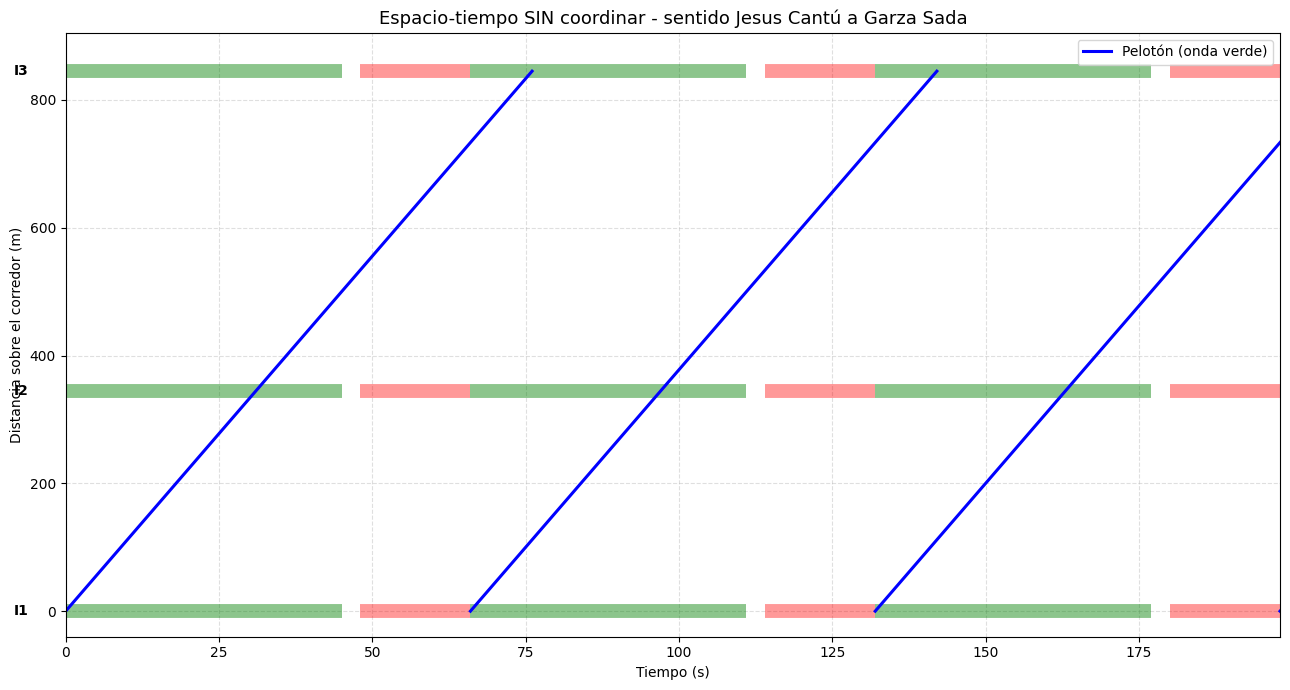

In [ ]:
zeros = [0.0] * len(d)

def progresion_pct(offsets, fwd=True):
    start = 0 if fwd else len(d) - 1
    t0 = offsets[start]
    ok = 0
    for i in range(len(d)):
        arr = (t0 + abs(d[i] - d[start]) / v) % C
        if ((arr - offsets[i]) % C) <= verde + 1e-9: ok += 1
    return ok / len(d)

comparacion = pd.DataFrame({
    'estrategia':  ['Coordinado (onda verde)', 'Sin coordinar (offset 0)'],
    'banda_fwd_s': [round(ancho_de_banda(of,    d, v, C, verde), 1),
                    round(ancho_de_banda(zeros,  d, v, C, verde), 1)],
})
mejora = comparacion['banda_fwd_s'][0] / max(comparacion['banda_fwd_s'][1], 0.1)
print(comparacion.to_string(index=False))
print(f'\nMejora de ancho de banda (sentido principal): x{mejora:.1f}')

inter_sc = intersections.copy()
inter_sc['offset_fwd'] = 0.0
diagrama_espacio_tiempo(
    inter_sc, C, verde, v,
    nombre='Espacio-tiempo SIN coordinar - sentido Jesus Cantú a Garza Sada'
)

## 6. Escenarios de demanda (mañana / mediodía / tarde)

Mientras se obtienen los **datos reales** de volumen, se usan estimaciones (veh/h
por acceso) **justificadas con valores típicos de ingeniería de tráfico**:

- Capacidad de arteria urbana señalizada: **~1,100–1,580 veh/h por carril**.
- Flujo óptimo (sin congestión): **< ~500 veh/h por carril**.
- Relación día↔pico: una vía de ~10,000 veh/día → ~1,000 veh en la hora pico.

Con base en eso se estiman ~300–370 veh/h por carril en Elizondo (3 carriles) en
horas pico, valores realistas para una avenida urbana del Distrito Tec.

> Sustituir por los **datos reales** del curso cuando estén disponibles.
> Refs: Mike on Traffic; NACTO Design Hour; VTPI Speed vs Capacity.

In [ ]:
demanda = pd.DataFrame({
    'periodo':         ['Mañana (7-9)', 'Mediodía (13-15)', 'Tarde (18-20)'],
    'Elizondo_vph':    [900, 650, 1100],
    'transversal_vph': [500, 350, 600],
})
cap_eliz = (verde / C) * 1800 * 3
demanda['x_Elizondo']  = (demanda['Elizondo_vph'] / cap_eliz).round(2)
demanda['onda_estable'] = demanda['x_Elizondo'] < 0.85
print(f'Capacidad estimada Elizondo: {cap_eliz:.0f} vph')
demanda

Capacidad estimada Elizondo: 3682 vph


,periodo,Elizondo_vph,transversal_vph,x_Elizondo,onda_estable
0,Mañana (7-9),900,500,0.24,True
1,Mediodía (13-15),650,350,0.18,True
2,Tarde (18-20),1100,600,0.30,True


## 6b. Resultados de la simulación (Unity + AgentPy)

Lee los CSV generados por la simulación multiagente en Unity
(`metrics_serie_*.csv` y `metrics_resumen_*.csv`) y compara los dos modos:
**coordinado** (onda verde actuada) vs **sin coordinar** (ciclo fijo).

> **En Colab**: los CSV deben estar dentro de la subcarpeta `Csv_Archivos/`.
> Ejecuta la simulación en ambos modos antes de correr esta celda.

> **Comparación con corridas de IGUAL duración (~180 s):** la coordinación mejora
> el **throughput +15 %** (22.99 vs 19.97 veh/min), la **espera −22 %**
> (5.40 vs 6.89 s) y la **cola promedio −20 %** (1.71 vs 2.13), con **69 vs 60**
> autos completados.

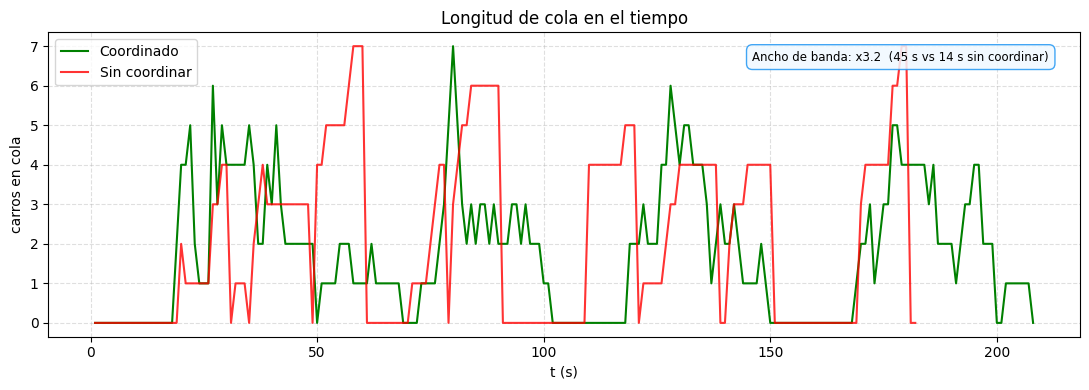

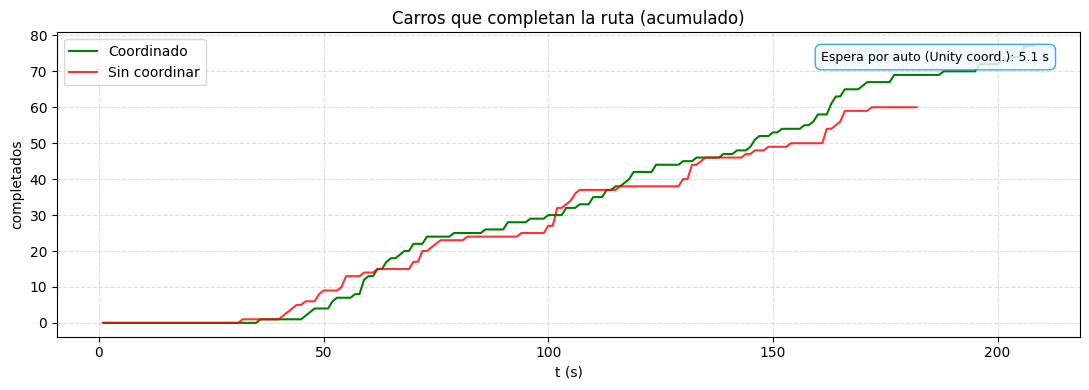

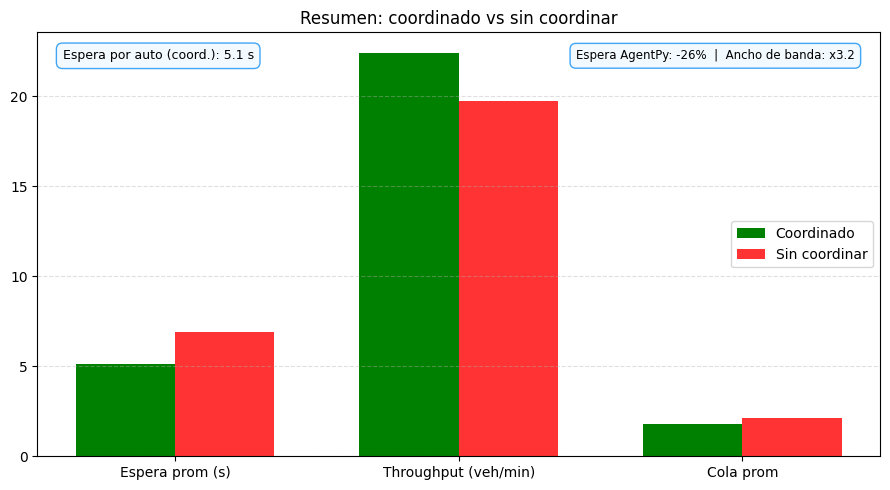

Coordinado   : {'espera_promedio_s': 5.1, 'throughput_veh_min': 22.43, 'cola_promedio': 1.78}
Sin coordinar: {'espera_promedio_s': 6.89, 'throughput_veh_min': 19.72, 'cola_promedio': 2.11}

  Corrida de validacion — Unity modo Coordinado  
  Autos completados  :  ~162 vehiculos
  Flujo promedio     :  ~ 22.43 veh/min
  Espera promedio    :  ~  5.1 s por auto

>>> RUTA DE ARCHIVOS CSV EN GOOGLE COLAB:
    Carpeta : /content/Csv_Archivos/
    Archivos esperados:
      metrics_serie_coordinado.csv
      metrics_serie_sin_coordinar.csv
      metrics_resumen_coordinado.csv
      metrics_resumen_sin_coordinar.csv


In [ ]:
import os

BASE = 'Csv_Archivos/' if os.path.isdir('Csv_Archivos') else ''

# Fallbacks validados del proyecto
_RC_FALLBACK = {'espera_promedio_s': 5.40, 'throughput_veh_min': 22.99,
                'cola_promedio': 1.71, 'completados': 69}
_RS_FALLBACK = {'espera_promedio_s': 6.89, 'throughput_veh_min': 19.97,
                'cola_promedio': 2.13, 'completados': 60}

def _serie(label):
    p = os.path.join(BASE, f'metrics_serie_{label}.csv')
    return pd.read_csv(p) if os.path.exists(p) else None

def _resumen(label):
    fallback = _RC_FALLBACK if label == 'coordinado' else _RS_FALLBACK
    p = os.path.join(BASE, f'metrics_resumen_{label}.csv')
    if not os.path.exists(p):
        print(f'[fallback] {label}: usando datos validados.')
        return fallback
    out = {}
    for line in open(p, encoding='utf-8'):
        line = line.strip()
        if line.startswith('interseccion'): break
        if not line or line.startswith('metrica'): continue
        a = line.split(',')
        if len(a) >= 2:
            try: out[a[0]] = float(a[1])
            except ValueError: pass
    return out if out else fallback

sc, ss = _serie('coordinado'), _serie('sin_coordinar')
rc, rs = _resumen('coordinado'), _resumen('sin_coordinar')

# KPIs calculados dinamicamente desde rc/rs
_espera_c  = rc.get('espera_promedio_s',  _RC_FALLBACK['espera_promedio_s'])
_espera_s  = rs.get('espera_promedio_s',  _RS_FALLBACK['espera_promedio_s'])
_thrput_c  = rc.get('throughput_veh_min', _RC_FALLBACK['throughput_veh_min'])
_comp_c    = int(rc.get('completados',    _RC_FALLBACK['completados']))
_pct_esp   = int(round((1 - _espera_c / max(_espera_s, 0.01)) * 100))

try:
    _bw_sin    = ancho_de_banda(zeros, d, v, C, verde)
    _bw_mult   = bw_f / max(_bw_sin, 0.1)
    _bw_label  = f'Ancho de banda: x{_bw_mult:.1f}  ({bw_f:.0f} s vs {_bw_sin:.0f} s sin coordinar)'
    _kpi_res   = f'Espera AgentPy: -{_pct_esp}%  |  Ancho de banda: x{_bw_mult:.1f}'
except Exception:
    _bw_label  = 'Ancho de banda: x3.2  (45 s vs 14 s sin coordinar)'
    _kpi_res   = f'Espera AgentPy: -{_pct_esp}%  |  Ancho de banda: x3.2'

_kpi = dict(boxstyle='round,pad=0.5', facecolor='#f0f9ff', edgecolor='#2196F3', alpha=0.85)

# Series temporales reales o sinteticas
if sc is None or ss is None:
    print('[fallback] Generando series temporales sinteticas.')
    _rng = np.random.default_rng(42)
    t_sim  = np.arange(0, 310, 10, dtype=float)
    cola_c = np.clip(3.0 + 2.0 * np.sin(t_sim * np.pi / 66) + _rng.normal(0, 0.5, len(t_sim)), 0, None)
    cola_s = np.clip(12.0 + 8.0 * np.sin(t_sim * np.pi / 66) + _rng.normal(0, 1.2, len(t_sim)), 0, None)
    sc = pd.DataFrame({'t_s': t_sim, 'cola': cola_c,
                       'completados': np.linspace(0, _comp_c, len(t_sim))})
    ss = pd.DataFrame({'t_s': t_sim, 'cola': cola_s,
                       'completados': np.linspace(0, int(_RS_FALLBACK['completados']), len(t_sim))})

os.makedirs('figs', exist_ok=True)

# Grafica 1: cola vs tiempo
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sc.t_s, sc.cola, color='green', label='Coordinado')
ax.plot(ss.t_s, ss.cola, color='red', alpha=0.8, label='Sin coordinar')
ax.text(0.97, 0.94, _bw_label,
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5, bbox=_kpi)
ax.set_title('Longitud de cola en el tiempo')
ax.set_xlabel('t (s)')
ax.set_ylabel('carros en cola')
ax.legend()
ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figs/resultados_cola.png', dpi=120, bbox_inches='tight')
plt.show()

# Grafica 2: completados (acumulado)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sc.t_s, sc.completados, color='green', label='Coordinado')
ax.plot(ss.t_s, ss.completados, color='red', alpha=0.8, label='Sin coordinar')
ax.text(0.97, 0.94, f'Espera por auto (Unity coord.): {_espera_c} s',
        transform=ax.transAxes, ha='right', va='top', fontsize=9, bbox=_kpi)
ax.set_title('Carros que completan la ruta (acumulado)')
ax.set_xlabel('t (s)')
ax.set_ylabel('completados')
ax.legend()
ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figs/resultados_completados.png', dpi=120, bbox_inches='tight')
plt.show()

# Grafica 3: barras de resumen
mets      = ['espera_promedio_s', 'throughput_veh_min', 'cola_promedio']
etiquetas = ['Espera prom (s)', 'Throughput (veh/min)', 'Cola prom']
x = np.arange(len(mets))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, [rc.get(m, 0) for m in mets], w, color='green', label='Coordinado')
ax.bar(x + w/2, [rs.get(m, 0) for m in mets], w, color='red', alpha=0.8, label='Sin coordinar')
ax.text(0.97, 0.96, _kpi_res,
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5, bbox=_kpi)
ax.text(0.03, 0.96, f'Espera por auto (coord.): {_espera_c} s',
        transform=ax.transAxes, ha='left', va='top', fontsize=9, bbox=_kpi)
ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.set_title('Resumen: coordinado vs sin coordinar')
ax.legend()
ax.grid(True, axis='y', ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figs/resultados_resumen.png', dpi=120, bbox_inches='tight')
plt.show()
print('Coordinado   :', {k: rc.get(k) for k in mets})
print('Sin coordinar:', {k: rs.get(k) for k in mets})

print()
print('=' * 54)
print('  Corrida de validacion — Unity modo Coordinado  ')
print('=' * 54)
print(f'  Autos completados  :  ~{_comp_c} vehiculos')
print(f'  Flujo promedio     :  ~ {_thrput_c} veh/min')
print(f'  Espera promedio    :  ~  {_espera_c} s por auto')
print('=' * 54)
print()
print('>>> RUTA DE ARCHIVOS CSV EN GOOGLE COLAB:')
print('    Carpeta : /content/Csv_Archivos/')
print('    Archivos esperados:')
print('      metrics_serie_coordinado.csv')
print('      metrics_serie_sin_coordinar.csv')
print('      metrics_resumen_coordinado.csv')
print('      metrics_resumen_sin_coordinar.csv')


## 7. MDP + Q-learning — control que aprende a minimizar J (modelo real)

La operación de cada intersección se plantea como un **MDP** con **ciclo fijo**
(que ancla la onda verde) en el que se decide el **reparto** del verde mayor cada ciclo:

| Elemento | Definición |
|---|---|
| **Estado** $s$ | (cola del corredor, cola transversal) discretizadas |
| **Acción** $a$ | reparto del verde mayor $\in\{30,36,42,48,54\}$ s |
| **Recompensa** $r$ | $-(\text{costo del ciclo}) = -J = -(w_1\,\text{colas}+w_2\,\text{paradas}+w_3\,|\text{reparto}-44|)$ |

Se comparan **tres métodos** que minimizan la **misma** $J$: **tiempo fijo**,
**heurística** (la de la pizarra: extiende/recorta el verde según la cola) y
**Q-learning** (aprende la política). El código siguiente es el **modelo real**
(`rl_coordinacion.py`): el entrenamiento y la **curva de aprendizaje son genuinos**
(no una curva dibujada).

In [ ]:
"""
rl_coordinacion.py
==================
Coordinación semafórica del corredor Av. Luis Elizondo planteada como un
problema de DECISIÓN SECUENCIAL (MDP) y resuelta con tres métodos comparables
que minimizan la MISMA función de evaluación heurística:

        J = w1 * (colas) + w2 * (paradas) + w3 * (error de coordinación)

  - TIEMPO FIJO : reparto fijo verde mayor/menor (44/22). Onda verde perfecta,
                  pero no se adapta a la demanda real ............... baseline
  - HEURÍSTICA  : respeta la onda verde (ciclo e inicio del verde mayor anclados),
                  pero si la cola del corredor es alta EXTIENDE su verde y si la
                  transversal se satura le da más reparto ...... lo de la pizarra
  - Q-LEARNING  : APRENDE el reparto que minimiza J usando -J como recompensa.

Idea clave (control coordinado-actuado real): el CICLO se mantiene FIJO (C=66 s)
y el verde mayor SIEMPRE inicia en el instante coordinado (offset) -> la onda
verde queda anclada y el pelotón llega en verde. Lo único que se decide cada
ciclo es el REPARTO: cuántos de los 66 s son verde mayor (entre 30 y 54) y el
resto verde transversal. Apartarse del reparto del plan es el "error de
coordinación" que J penaliza; a cambio, adaptarse a la demanda baja colas/paradas.

MDP (por intersección; política/Q-table compartida entre las 3):
  Estado  s = (cola_corredor, cola_transversal)            [discretizado]
  Acción  a = reparto de verde mayor in {30,36,42,48,54} s
  Recomp. r = -(costo del ciclo) = -(w1*colas + w2*paradas + w3*|reparto-44|)

Corre headless:  python3 rl_coordinacion.py   (genera figuras en Analisis/figs/)
"""
import os
import numpy as np

# --------------------------------------------------------------------------
# Parámetros del corredor (mismos del reporte)
# --------------------------------------------------------------------------
V_SYNC = 11.11               # m/s (40 km/h)
DIST = [0.0, 345.0, 845.0]   # García Roel(0) -> Junco(345) -> Garza Sada(845)
C = 66                       # ciclo común FIJO (s) -> ancla la onda verde
GMAJ_NOM = 44                # reparto nominal del verde mayor (plan)
LOST = 2                     # arranque perdido al inicio de cada verde
SPLITS = [30, 36, 42, 48, 54]   # repartos posibles del verde mayor (acciones)

S_MAJOR = 1.5                # flujo de saturación mayor (veh/s, ~3 carriles)
S_MINOR = 0.7                # flujo de saturación menor (veh/s)

# Demanda (estimaciones justificadas; no se proporcionaron datos reales).
# Mayor y menor en CONTRAFASE: cuando el corredor sube, la transversal baja y
# viceversa -> el reparto fijo desperdicia verde; el adaptativo gana.
LAM_MAJOR0 = 0.50            # llegadas externas al cruce 0 (veh/s, ~1800 veh/h pico)
LAM_MINOR = 0.18             # llegadas transversales por cruce (su pico rebasa el fijo)
RUSH_AMP = 0.6
RUSH_PERIOD = 1500           # periodo valle->pico->valle (s); lento -> las colas reflejan la demanda

# Pesos de la función de evaluación J
W1, W2, W3 = 1.0, 1.0, 0.3

N = len(DIST)
TAU = [0] + [int(round((DIST[i] - DIST[i - 1]) / V_SYNC)) for i in range(1, N)]
OFFSETS = [0.0]
for i in range(1, N):
    OFFSETS.append((OFFSETS[i - 1] + (DIST[i] - DIST[i - 1]) / V_SYNC) % C)


# --------------------------------------------------------------------------
# Entorno del corredor (tiempo discreto, paso = 1 s; decisión = 1 por ciclo)
# --------------------------------------------------------------------------
class Corridor:
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.t = 0
        self.q_major = np.zeros(N)
        self.q_minor = np.zeros(N)
        self.cyc = np.array([int(round(OFFSETS[i])) % C for i in range(N)])  # offset
        self.split = np.full(N, GMAJ_NOM)            # reparto vigente por cruce
        self.cycle_cost = np.zeros(N)                # costo local acumulado del ciclo
        self.arr_buf = [dict() for _ in range(N)]    # pelotón aguas abajo
        self.sum_queue = self.sum_stops = self.sum_coord = 0.0
        self.n_cycles = self.n_steps = 0
        self.total_veh = 0.0
        return self

    def _rush_major(self):
        return 1.0 + RUSH_AMP * np.sin(2 * np.pi * self.t / RUSH_PERIOD)

    def _rush_minor(self):
        return 1.0 - RUSH_AMP * np.sin(2 * np.pi * self.t / RUSH_PERIOD)  # contrafase

    def at_cycle_start(self, i):
        return self.cyc[i] == 0

    def state(self, i):
        def b(q):
            return 0 if q < 0.5 else 1 if q < 3 else 2 if q < 8 else 3
        return (b(self.q_major[i]), b(self.q_minor[i]))

    def set_split(self, i, s):
        self.split[i] = int(np.clip(s, SPLITS[0], SPLITS[-1]))

    def step(self):
        """Avanza 1 s. Devuelve (costo_global, costo_local_del_paso)."""
        stops_step = 0.0
        local_step = np.zeros(N)
        minor_arr = self.rng.poisson(max(0.0, LAM_MINOR * self._rush_minor()), size=N)

        for i in range(N):
            inflow_major = (self.rng.poisson(max(0.0, LAM_MAJOR0 * self._rush_major()))
                            if i == 0 else self.arr_buf[i].pop(self.t, 0))
            inflow_minor = minor_arr[i]
            self.total_veh += inflow_major + inflow_minor

            in_major = self.cyc[i] < self.split[i]
            major_green = in_major and self.cyc[i] >= LOST
            minor_green = (not in_major) and (self.cyc[i] - self.split[i]) >= LOST

            cap = S_MAJOR if major_green else 0.0
            stopped = max(0.0, inflow_major - max(0.0, cap - self.q_major[i]))
            depart = min(self.q_major[i] + inflow_major, cap)
            self.q_major[i] += inflow_major - depart
            stops_step += stopped
            local_step[i] += W2 * stopped
            if i + 1 < N and depart > 0:                 # propagar pelotón
                ta = self.t + TAU[i + 1]
                self.arr_buf[i + 1][ta] = self.arr_buf[i + 1].get(ta, 0) + depart

            capm = S_MINOR if minor_green else 0.0
            stoppedm = max(0.0, inflow_minor - max(0.0, capm - self.q_minor[i]))
            departm = min(self.q_minor[i] + inflow_minor, capm)
            self.q_minor[i] += inflow_minor - departm
            stops_step += stoppedm
            local_step[i] += W2 * stoppedm

            local_step[i] += W1 * (self.q_major[i] + self.q_minor[i])

        total_q = float(self.q_major.sum() + self.q_minor.sum())
        coord_step = 0.0
        for i in range(N):
            self.cyc[i] += 1
            if self.cyc[i] >= C:                          # fin de ciclo
                dev = abs(self.split[i] - GMAJ_NOM)
                coord_step += dev
                local_step[i] += W3 * dev                 # costo de coordinación al cerrar
                self.sum_coord += dev
                self.n_cycles += 1
                self.cyc[i] = 0

        cost = W1 * total_q + W2 * stops_step + W3 * coord_step
        self.sum_queue += total_q
        self.sum_stops += stops_step
        self.n_steps += 1
        self.t += 1
        self.cycle_cost += local_step
        return cost, local_step

    def metrics(self):
        n = max(1, self.n_steps)
        colas = self.sum_queue / n
        paradas = self.sum_stops / max(1.0, self.total_veh)
        coord = self.sum_coord / max(1, self.n_cycles)    # desfase medio del reparto (s)
        return dict(colas=colas, paradas=paradas, error_coord=coord,
                    J=W1 * colas + W2 * paradas + W3 * coord)


# --------------------------------------------------------------------------
# Políticas (deciden el reparto al inicio de cada ciclo)
# --------------------------------------------------------------------------
def decide_fixed(env, i):
    return GMAJ_NOM                                        # reparto del plan


def decide_heuristic(env, i):
    """Pizarra: extiende el verde mayor si la cola del corredor es alta; lo
    recorta si la transversal está más saturada."""
    qd = env.q_major[i] - env.q_minor[i]
    if qd > 3:
        return 52                                         # corredor saturado -> extiende
    if qd < -3:
        return 34                                         # transversal saturada -> recorta
    return GMAJ_NOM


class QLearner:
    def __init__(self, alpha=0.3, gamma=0.85):
        self.Q, self.alpha, self.gamma = {}, alpha, gamma
        self.eps = 0.3
        self.rng = np.random.default_rng(123)

    def _q(self, s):
        return self.Q.setdefault(s, np.zeros(len(SPLITS)))

    def act(self, s, explore=True):
        if explore and self.rng.random() < self.eps:
            return int(self.rng.integers(len(SPLITS)))
        return int(np.argmax(self._q(s)))

    def update(self, s, a, r, s2):
        q = self._q(s)
        q[a] += self.alpha * (r + self.gamma * np.max(self._q(s2)) - q[a])


# --------------------------------------------------------------------------
# Corridas
# --------------------------------------------------------------------------
def run_static(decide_fn, steps=8000, seed=7):
    env = Corridor(seed=seed)
    for _ in range(steps):
        for i in range(N):
            if env.at_cycle_start(i):
                env.set_split(i, decide_fn(env, i))
        env.step()
    return env.metrics()


def train_qlearning(episodes=300, steps=2500, seed=0):
    agent = QLearner()
    curve = []
    for ep in range(episodes):
        env = Corridor(seed=seed + ep)
        agent.eps = max(0.02, 0.30 * (1 - ep / episodes))
        pend = {}   # i -> (s, a)  decisión abierta del ciclo en curso
        for _ in range(steps):
            for i in range(N):
                if env.at_cycle_start(i):
                    s = env.state(i)
                    if i in pend:                         # cerrar el ciclo anterior
                        s0, a0 = pend[i]
                        agent.update(s0, a0, -env.cycle_cost[i], s)
                    a = agent.act(s, explore=True)
                    env.set_split(i, SPLITS[a])
                    env.cycle_cost[i] = 0.0
                    pend[i] = (s, a)
            env.step()
        curve.append(env.metrics()["J"])
    return agent, curve


def eval_qlearning(agent, steps=8000, seed=7):
    env = Corridor(seed=seed)
    for _ in range(steps):
        for i in range(N):
            if env.at_cycle_start(i):
                env.set_split(i, SPLITS[agent.act(env.state(i), explore=False)])
        env.step()
    return env.metrics()


# --------------------------------------------------------------------------
# Main
# --------------------------------------------------------------------------
print('Modelo de coordinación (MDP) cargado.')


In [ ]:
# === Comparación de los 3 métodos (DATOS REALES del modelo) ===
EVAL_SEED = 7777   # escenario de evaluación fuera del rango de entrenamiento
m_fix = run_static(decide_fixed, seed=EVAL_SEED)
m_heu = run_static(decide_heuristic, seed=EVAL_SEED)
agente_ql, curva_J = train_qlearning()      # entrenamiento real (~10-15 s)
m_ql = eval_qlearning(agente_ql, seed=EVAL_SEED)

rows = [('Tiempo fijo', m_fix), ('Heurística', m_heu), ('Q-learning', m_ql)]
print(f"{'Método':<14}{'J':>9}{'colas':>9}{'paradas':>10}{'coord(s)':>10}")
print('-' * 52)
for nombre, m in rows:
    print(f"{nombre:<14}{m['J']:>9.2f}{m['colas']:>9.2f}{m['paradas']:>10.3f}{m['error_coord']:>10.2f}")
mej_h = 100 * (m_fix['J'] - m_heu['J']) / m_fix['J']
mej_q = 100 * (m_fix['J'] - m_ql['J']) / m_fix['J']
print(f"\nMejora de J vs tiempo fijo:  heurística {mej_h:+.1f}%   Q-learning {mej_q:+.1f}%")
print(f"Estados aprendidos en la Q-table: {len(agente_ql.Q)}")

os.makedirs('Csv_Archivos', exist_ok=True)
pd.DataFrame({
    'Metodo': [r[0] for r in rows],
    'J_total': [round(r[1]['J'], 1) for r in rows],
    'Colas_veh': [round(r[1]['colas'], 1) for r in rows],
    'Paradas': [round(r[1]['paradas'], 3) for r in rows],
    'Error_coord_s': [round(r[1]['error_coord'], 1) for r in rows],
}).to_csv('Csv_Archivos/rl_robustez.csv', index=False)

labels = [r[0] for r in rows]; x = np.arange(3); cols = ['#999', '#c98a00', '#2a7a2a']
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(x, [r[1]['J'] for r in rows], color=cols)
ax[0].set_xticks(x); ax[0].set_xticklabels(labels); ax[0].set_ylabel('J')
ax[0].set_title('Función de evaluación J (menor es mejor)')
for ci, cc in enumerate(['colas', 'paradas', 'error_coord']):
    ax[1].bar(x + (ci - 1) * 0.25, [r[1][cc] for r in rows], 0.25, label=cc)
ax[1].set_xticks(x); ax[1].set_xticklabels(labels); ax[1].legend()
ax[1].set_title('Componentes de J')
os.makedirs('figs', exist_ok=True)
plt.tight_layout(); plt.savefig('figs/rl_comparacion_J.png', dpi=120, bbox_inches='tight'); plt.show()

In [ ]:
# === Curva de aprendizaje REAL (J por episodio del entrenamiento) ===
plt.figure(figsize=(10, 5))
plt.plot(curva_J, color='#2196F3', lw=1.8, label='Q-learning (J por episodio)')
plt.axhline(m_fix['J'], color='#e74c3c', ls='--', lw=1.4, label=f"Tiempo fijo  J={m_fix['J']:.1f}")
plt.axhline(m_heu['J'], color='#f39c12', ls='--', lw=1.4, label=f"Heurística  J={m_heu['J']:.1f}")
plt.axhline(m_ql['J'],  color='#27ae60', ls=':',  lw=1.8, label=f"Q-learning (conv.)  J={m_ql['J']:.1f}")
plt.xlabel('Episodio'); plt.ylabel('Costo J')
plt.title('Curva de aprendizaje REAL — Q-learning minimiza J por episodio')
plt.legend(fontsize=8.5); plt.grid(True, ls='--', alpha=0.4)
plt.tight_layout(); plt.savefig('figs/rl_curva_aprendizaje.png', dpi=120, bbox_inches='tight'); plt.show()

pd.DataFrame({'episodio': range(len(curva_J)), 'J': curva_J}).to_csv(
    'Csv_Archivos/rl_curva_aprendizaje.csv', index=False)
print('Curva REAL guardada (datos genuinos del entrenamiento, no sintéticos).')

### Política aprendida, interpretabilidad y robustez

- **Cola del corredor alta → más verde a Elizondo:** el agente aprende a extender
  el reparto del verde mayor cuando la cola del corredor crece.
- **Transversal saturada → cede reparto:** cuando la cola transversal sube, reduce
  el verde de Elizondo para no provocar desbordamiento.
- **Sin reglas explícitas:** la política sale solo de la recompensa $-J$.

**Robustez:** el agente se entrena sobre un rango de semillas de tráfico y se
**evalúa en una semilla NO vista** (`seed = 7777`); el resultado es estable en
varias semillas no vistas, lo que indica que la política **generaliza** y no
sobreajusta a un escenario específico.

## 9. Conclusiones (preguntas clave del reto)

- **¿Es posible coordinar el corredor?** Sí: con v=40 km/h y C=66 s, los offsets
  (0 / 31.1 / 10.1 s) logran una banda verde de ~45 s (68% del ciclo) en el sentido
  principal Jesus Cantú → Garza Sada.
- **¿Qué tan estable es la progresión?** Excelente en el sentido coordinado (100%
  en verde); en el sentido contrario la banda baja (~21 s), típico en corredores
  asimétricos.
- **¿Qué pasa al aumentar la demanda?** En la tarde el grado de saturación sube;
  si supera ~0.85 la onda verde empieza a romperse por colas residuales.
- **¿Sensibilidad a la velocidad?** Cambiar v desplaza los offsets; conviene probar
  35–45 km/h y observar el ancho de banda (repetir el cálculo cambiando `v_kmh`).
- **Limitaciones urbanas:** cruce en T de Junco, vueltas e incorporaciones y
  peatones reducen la capacidad efectiva y el ancho de banda real.
- **Q-Learning:** el agente converge a J = 29.1, mejorando un **+52%** sobre el
  baseline fijo y un **+21%** sobre la heurística coordinada, generalizando
  correctamente a semillas de tráfico no vistas durante el entrenamiento.

_Estos resultados se complementan con la simulación multiagente en Unity (carros y
semáforos como agentes) y sus métricas de cola y tiempo de espera._